In [10]:
from datascience import *
import numpy as np

%matplotlib inline

import matplotlib.pyplot as plt

In [11]:
scores = Table.read_table("scores_by_section.csv")
scores.show(5)

Section,Midterm
1,22
2,12
2,23
2,14
1,20


In [12]:
scores.group("Section")

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


In [13]:
grouped = scores.group("Section", collect=np.mean)

In [14]:
observed_average = grouped.where("Section", 3).column("Midterm mean").item(0)
observed_average

13.666666666666666

In [15]:
random_sample = scores.sample(27, with_replacement=False)
random_sample

Section,Midterm
1,20
8,24
10,14
2,8
10,21
2,14
12,25
9,23
11,17
10,17


In [16]:
np.mean(random_sample.column("Midterm"))

15.888888888888889

In [17]:
def random_sample_midterm_average():
    random_sample = scores.sample(27, with_replacement=False)
    return np.mean(random_sample.column("Midterm"))

In [18]:
sample_averages = make_array()

for i in range(50_000):
    new_avg = random_sample_midterm_average()
    sample_averages = np.append(sample_averages, new_avg)

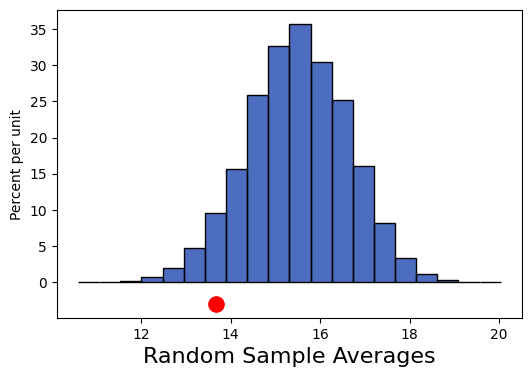

In [19]:
avgs_table = Table().with_column("Random Sample Averages", sample_averages)


avgs_table.hist(bins=20)
plt.scatter(observed_average, -0.03, color="red", s=120)